In [ ]:
!pip install trimesh -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 15.6 MB/s eta 0:00:00


In [ ]:
import json
import os

from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/pointcloud/params'

# Create the directory if it doesn't already exist
os.makedirs(save_dir, exist_ok=True)

file_path = os.path.join(save_dir, 'parameters.json')

# 1. Define your program parameters in a dictionary
parameters = {
    "pixel_pitch": 3.74e-6,
    "wavelength": 632.8e-9,
    "axis_dist": 0.9999,
    "img_width": 3840,
    "img_height": 2180,
    "target_vram_gb": 10.0,
    "generate_hologram": True,
    "optimize_gs": True,
    "img_path": "/content/drive/MyDrive/pointcloud/CGHs/zmienNazwe.png",
}

# 2. Save the parameters to a JSON file
with open(file_path, "w") as json_file:
    # indent=4 formats the file to be easily readable by humans
    json.dump(parameters, json_file, indent=4)

print("Parameters successfully saved to: ",file_path)

Mounted at /content/drive
Parameters successfully saved to:  /content/drive/MyDrive/pointcloud/params/parameters.json


In [ ]:
params_path = '/content/drive/MyDrive/pointcloud/params/parameters.json'

with open(params_path, "r") as json_file:
    loaded_params = json.load(json_file)

# Load the global program parameters

pixel_pitch = loaded_params["pixel_pitch"]
wavelength = loaded_params["wavelength"]
axis_dist = loaded_params["axis_dist"]
width = loaded_params["img_width"]
height = loaded_params["img_height"]
target_vram_gb = loaded_params["target_vram_gb"]
generate_hologram = loaded_params["generate_hologram"]
optimize_gs = loaded_params["optimize_gs"]
img_path = loaded_params["img_path"]

# instrukcja warunkowa optymalizacji GS
if generate_hologram != True:
    optimize_gs = False
    print("Tryb odczytu jest włączony. Ustaw generate_holograms na TRUE")

In [ ]:
!pip install moderngl trimesh pyrr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.2/51.2 kB 5.5 MB/s eta 0:00:00


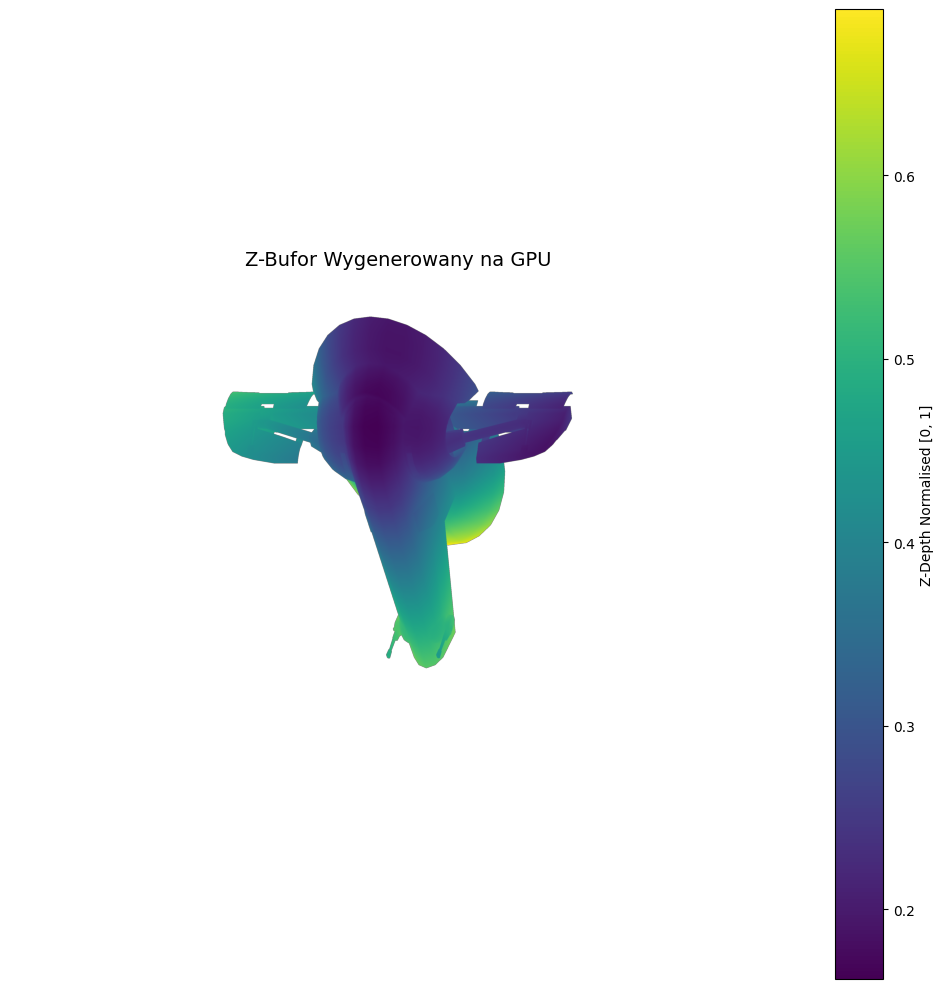

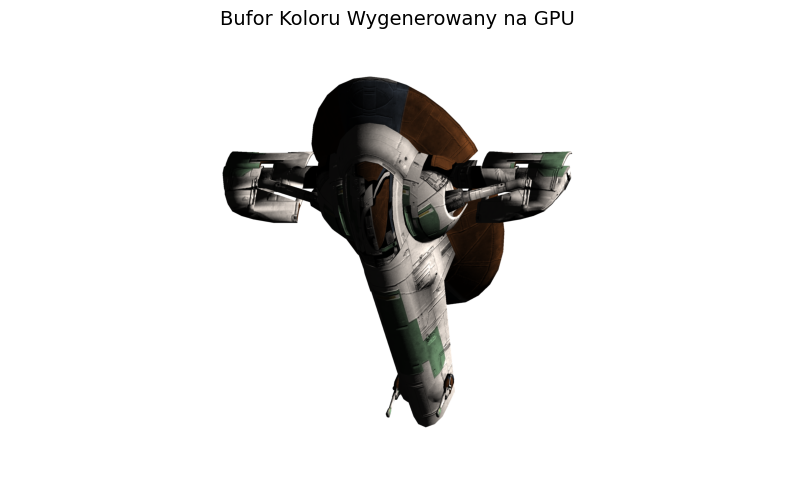

In [ ]:
import trimesh
import torch
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt


filename = "/content/drive/MyDrive/pointcloud/slaveI/source/Firespray.obj"


# force='scene' gwarantuje, że trimesh nie scali geometrii w jedną bryłę
scene = trimesh.load(filename, force='scene')



from pyrr import Matrix44, Vector3 # Lekka biblioteka do macierzy transformacji
import moderngl
from PIL import Image

# =====================================================================
# KROK 2: INICJALIZACJA KONTEKSTU GPU (Headless)
# =====================================================================
# Tworzymy niezależny kontekst OpenGL bez otwierania okna systemu operacyjnego
ctx = moderngl.create_context(standalone=True, backend='egl')
ctx.enable(moderngl.DEPTH_TEST) # Włączenie sprzętowego Z-bufora

# Dodaj brakującą inicjalizację bufora:
color_renderbuffer = ctx.renderbuffer((width, height), components=4, dtype='f4')
depth_renderbuffer = ctx.depth_renderbuffer((width, height))
fbo = ctx.framebuffer(color_attachments=[color_renderbuffer], depth_attachment=depth_renderbuffer)



# =====================================================================
# KROK 3: SHADERY
# =====================================================================

# Vertex Shader
vertex_shader = '''
#version 330 core

in vec3 in_position;
in vec3 in_normal;
in vec2 in_uv;

out vec3 v_world_pos;
out vec3 v_normal;
out vec2 v_uv;

uniform mat4 u_proj;
uniform mat4 u_view;
uniform mat4 u_model;

void main() {
    vec4 world_pos = u_model * vec4(in_position, 1.0);
    v_world_pos = world_pos.xyz;

    // Transformacja wektora normalnego do przestrzeni świata
    v_normal = mat3(transpose(inverse(u_model))) * in_normal;
    v_uv = in_uv;

    gl_Position = u_proj * u_view * world_pos;
}
'''

# Fragment Shader
fragment_shader = '''
#version 330 core

in vec2 v_uv;
in vec3 v_normal;
in vec3 v_world_pos;

out vec4 fragColor;

uniform sampler2D u_diffuse;   // location = 0
uniform sampler2D u_specular;  // location = 1 (_s)
uniform sampler2D u_emission;  // location = 2 (_emis)
uniform sampler2D u_normalmap; // location = 3 (_cn)

uniform bool u_has_specular;
uniform bool u_has_emission;
uniform bool u_has_normalmap;

uniform vec3 u_camera_pos;
uniform vec3 u_light_dir;

// Nowe uniformy do kontroli oświetlenia
uniform vec3 u_light_color;       // np. vec3(1.0, 0.95, 0.9) - lekko ciepłe światło
uniform float u_light_intensity;  // np. 2.0 - 3.5 dla mocnego, ostrego słońca
uniform float u_ambient_strength; // np. 0.05 - 0.1 dla głębszych, kontrastowych cieni

void main() {
    vec4 base = texture(u_diffuse, v_uv);

    // 1. Dekodowanie normalnych
    vec3 N = normalize(v_normal);
    if (u_has_normalmap) {
        vec4 raw_cn = texture(u_normalmap, v_uv);
        float nx = raw_cn.r * 2.0 - 1.0;
        float ny = raw_cn.g * 2.0 - 1.0;
        float nz = sqrt(max(0.0, 1.0 - nx * nx - ny * ny));
        vec3 decoded_normal = vec3(nx, ny, nz);
        N = normalize(mix(N, decoded_normal, 0.6)); // silniejszy wpływ mapy normalnych
    }

    // 2. Wektory kierunkowe
    vec3 L = normalize(u_light_dir);
    vec3 V = normalize(u_camera_pos - v_world_pos);
    vec3 H = normalize(L + V);

    // 3. Składowa dyfuzyjna (światło bezpośrednie)
    float diff = max(dot(N, L), 0.0);
    vec3 diffuse = diff * base.rgb * u_light_color * u_light_intensity;

    // 4. Składowa otoczenia (Ambient) - rozjaśnia cienie
    vec3 ambient = u_ambient_strength * base.rgb;

    // 5. Składowa zwierciadlana (Specular) - mocny błysk
    float spec_mask = 1.0;
    if (u_has_specular) {
        spec_mask = texture(u_specular, v_uv).r;
    }
    // Wykładnik 64.0 daje węższy, bardziej skoncentrowany i "gorący" punkt odbicia
    float spec = pow(max(dot(N, H), 0.0), 64.0) * spec_mask;
    vec3 specular = spec * u_light_color * (u_light_intensity * 1.5);

    // 6. Emisja (ekrany/silniki)
    vec3 emissive = vec3(0.0);
    if (u_has_emission) {
        emissive = texture(u_emission, v_uv).rgb * 2.5; // Mocniejsze jarzenie diod
    }

    // Złożenie ostatecznego koloru
    vec3 final_color = ambient + diffuse + specular + emissive;

    fragColor = vec4(final_color, gl_FragCoord.z);
}
'''
prog = ctx.program(vertex_shader=vertex_shader, fragment_shader=fragment_shader)


gpu_parts = []
all_vertices = []

for name, mesh in scene.geometry.items():
    if not hasattr(mesh.visual, 'uv') or mesh.visual.uv is None:
        continue

    positions = mesh.vertices.astype('f4')
    normals = mesh.vertex_normals.astype('f4')
    uvs = mesh.visual.uv.astype('f4')
    indices = mesh.faces.flatten().astype('i4')

    all_vertices.append(positions)

    # Przeplot atrybutów: pozycja (3f), normalna (3f), uv (2f)
    vertex_data = np.hstack([positions, normals, uvs])

    vbo = ctx.buffer(vertex_data.tobytes())
    ibo = ctx.buffer(indices.tobytes())

    # in_uv odpowiada nazwie zmiennej wejściowej w vertex shaderze
    vao = ctx.vertex_array(
        prog,
        [(vbo, '3f 3f 2f', 'in_position', 'in_normal', 'in_uv')],
        index_buffer=ibo
    )

    gpu_parts.append({
        'name': name.lower(),
        'vao': vao
    })


#======================================
# WCZYTANIE TEKSTUR
#======================================

# 1. Funkcja pomocnicza ładowania tekstury


# =====================================================================
# KROK 4: MACIERZ ORTOGRAFICZNA (Z kompensacją Aspect Ratio)
# =====================================================================
vertices = np.vstack(all_vertices)

x_min, y_min, z_min = vertices.min(axis=0)
x_max, y_max, z_max = vertices.max(axis=0)

x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min
# Używamy pełnego zakresu modelu z marginesem 20%, tak jak w kodzie CPU
max_range = max(x_range, y_range, z_range) * 1.2

# Odtwarzamy idealną, jednorodną skalę z kodu programowego CPU
scale = min(width, height) / max_range

# Zamiast przypisywać sztywny 'max_range' do osi X i Y,
# dostosowujemy rozpiętość kamery do fizycznych pikseli bufora.
# To gwarantuje zachowanie proporcji nawet na asymetrycznych ekranach.
x_span = width / (2.0 * scale)
y_span = height / (2.0 * scale)

# Oś Z nie podlega sprzętowemu dopasowaniu do ekranu (Viewport Transform),
# więc jej rozpiętość zostawiamy zgodnie z gabarytami modelu (połowa zakresu).
z_span = max_range / 2.0

x_center = (x_max + x_min) / 2.0
y_center = (y_max + y_min) / 2.0
z_center = (z_max + z_min) / 2.0

near_plane = z_center - z_span
far_plane = z_center + z_span

# centrowanie obiektu



# ... (KROK 4 pozostaje bez zmian) ...

# Budowa macierzy ortograficznej
ortho_matrix = Matrix44.orthogonal_projection(
    x_center - x_span, x_center + x_span,
    y_center - y_span, y_center + y_span,
    near_plane, far_plane
).astype('f4')

identity_mat = Matrix44.identity().astype('f4')

# 1. Kąty obrotu w stopniach (zmień według potrzeb)
yaw_deg   = 20.0   # Obrót wokół osi Y (lewo / prawo)
pitch_deg = -45.0   # Obrót wokół osi X (góra / dół)
roll_deg  = 0.0    # Obrót wokół osi Z (przechył na boki)

# Konwersja na radiany
yaw   = np.radians(yaw_deg)
pitch = np.radians(pitch_deg)
roll  = np.radians(roll_deg)

# 2. Tworzenie macierzy przesunięć do i ze środka geometrii
center = Vector3([x_center, y_center, z_center])
trans_to_origin = Matrix44.from_translation(-center)
trans_back      = Matrix44.from_translation(center)

# 3. Tworzenie macierzy rotacji dla poszczególnych osi
rot_x = Matrix44.from_x_rotation(pitch)
rot_y = Matrix44.from_y_rotation(yaw)
rot_z = Matrix44.from_z_rotation(roll)

# Połączenie rotacji (kolejność mnożenia: Z * Y * X)
rot_matrix = rot_z * rot_y * rot_x

# 4. Ostateczna macierz modelu: Przesuń do (0,0,0) -> Obróć -> Wróć na pozycję
model_matrix = (trans_back * rot_matrix * trans_to_origin).astype('f4')

# 5. Przesłanie zaktualizowanej macierzy modelu do shadera
prog['u_model'].write(model_matrix.tobytes())

# Pozostałe macierze:
prog['u_proj'].write(ortho_matrix.tobytes())
prog['u_view'].write(Matrix44.identity().astype('f4').tobytes())


prog['u_camera_pos'].value = (x_center, y_center, far_plane + 10.0)
prog['u_light_dir'].value = (1.0, 0.5, 1.0)

prog['u_light_color'].value = (1.0, 1.0, 1.0)
prog['u_light_intensity'].value = 4.0  # Zwiększaj tę wartość według uznania (np. 3.0, 4.0)
prog['u_ambient_strength'].value = 0.08  # Mniejsza wartość = bardziej dramatyczne, czarne cienie kosmiczne

# =====================================================================
# KROK 5: BUFORY GPU (VBO, IBO, FBO) I TEKSTURY
# =====================================================================



#############################
# 1. Wczytanie tekstury modelu
def load_texture(filename):
    base_dir = "/content/drive/MyDrive/pointcloud/slaveI"
    path = os.path.join(base_dir, filename)
    img = Image.open(path).transpose(Image.FLIP_TOP_BOTTOM).convert('RGB')
    tex = ctx.texture(img.size, 3, img.tobytes())
    tex.filter = (moderngl.LINEAR_MIPMAP_LINEAR, moderngl.LINEAR)
    tex.build_mipmaps()
    return tex

# Wczytanie map dla poszczególnych sekcji
textures = {
    'main': load_texture('slave1_main(Boba).png'),
    'main_specular': load_texture('slave1_main_s.png'),
    'main_normalmap': load_texture('slave1_main_cn.png'),

    'cockpit_1': load_texture('firespray_cockpit_1.png'),
    'cockpit_1_specular': load_texture('firespray_cockpit_1_s.png'),
    'cockpit_1_normalmap': load_texture('firespray_cockpit_1_cn.png'),
    'cockpit_1_emission': load_texture('firespray_cockpit_1_emis.png'),

    'cockpit_2': load_texture('firespray_cockpit_2.png'),
    'cockpit_2_specular': load_texture('firespray_cockpit_2_s.png'),
    'cockpit_2_normalmap': load_texture('firespray_cockpit_2_cn.png'),
    'cockpit_2_emission': load_texture('firespray_cockpit_2_emis.png'),

    'cockpit_3': load_texture('firespray_cockpit_3.png'),
    'cockpit_3_specular': load_texture('firespray_cockpit_3_s.png'),
    'cockpit_3_normalmap': load_texture('firespray_cockpit_3_cn.png'),

    'engine': load_texture('slave1_engine1.png'),
    'engine_specular': load_texture('slave1_engine1_s.png'),
    'engine_normalmap': load_texture('slave1_engine1_cn.png'),
    'engine_emission': load_texture('slave1_engine_on.png'),

    'booster': load_texture('slave1_booster_s01.png'),
    'booster_specular': load_texture('slave1_booster_s01_s.png'),
    'booster_normalmap': load_texture('slave1_booster_s01_cn.png'),

    'glass': load_texture('slave1_glass.png'),
    'glass_specular': load_texture('slave1_glass_s.png'),

    'gun': load_texture('slave1_gun1.png'),
    'gun_specular': load_texture('slave1_gun1_s.png'),
    'gun_normalmap': load_texture('slave1_gun1_cn.png'),

    'rear': load_texture('slave1_rear(Boba).png'),
    'rear_specular': load_texture('slave1_rear_s.png'),
    'rear_normalmap': load_texture('slave1_rear_cn.png'),
}





prog['u_diffuse'].value = 0
prog['u_specular'].value = 1
prog['u_emission'].value = 2
prog['u_normalmap'].value = 3

fbo.use()
fbo.clear(0.0, 0.0, 0.0, 1.0, depth=1.0)

# 4. Pętla renderowania: Przełączanie tekstur na podstawie materiału
def render_frame():

    for part in gpu_parts:
        name = part['name'].lower()
        vao = part['vao']

        # Dopasowanie tekstury do nazwy części/materiału z pliku .obj
        if 'rear' in name:
            textures['rear'].use(location=0)
            textures['rear_specular'].use(location=1)
            textures['rear_normalmap'].use(location=3)
            prog['u_has_specular'].value = True
            prog['u_has_normalmap'].value = True
        elif 'cockpit_1' in name:
            textures['cockpit_1'].use(location=0)
            textures['cockpit_1_specular'].use(location=1)
            textures['cockpit_1_normalmap'].use(location=3)
            textures['cockpit_1_emission'].use(location=2)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = True
            prog['u_has_normalmap'].value = True
        elif 'cockpit_2' in name:
            textures['cockpit_2'].use(location=0)
            textures['cockpit_2_specular'].use(location=1)
            textures['cockpit_2_normalmap'].use(location=3)
            textures['cockpit_2_emission'].use(location=2)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = True
            prog['u_has_normalmap'].value = True
        elif 'cockpit_3' in name:
            textures['cockpit_3'].use(location=0)
            textures['cockpit_3_specular'].use(location=1)
            textures['cockpit_3_normalmap'].use(location=3)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = False
            prog['u_has_normalmap'].value = True
        elif 'engine' in name:
            textures['engine'].use(location=0)
            textures['engine_specular'].use(location=1)
            textures['engine_normalmap'].use(location=3)
            textures['engine_emission'].use(location=2)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = True
            prog['u_has_normalmap'].value = True
        elif 'booster' in name:
            textures['booster'].use(location=0)
            textures['booster_specular'].use(location=1)
            textures['booster_normalmap'].use(location=3)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = False
            prog['u_has_normalmap'].value = True
        elif 'glass' in name:
            textures['glass'].use(location=0)
            textures['glass_specular'].use(location=1)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = False
            prog['u_has_normalmap'].value = False
        elif 'gun' in name:
            textures['gun'].use(location=0)
            textures['gun_specular'].use(location=1)
            textures['gun_normalmap'].use(location=3)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = False
            prog['u_has_normalmap'].value = True
        else:
            # Domyślnie kadłub główny
            textures['main'].use(location=0)
            textures['main_specular'].use(location=1)
            textures['main_normalmap'].use(location=3)
            prog['u_has_specular'].value = True
            prog['u_has_emission'].value = False
            prog['u_has_normalmap'].value = True

        vao.render()

render_frame()

# =====================================================================
# KROK 7: POBRANIE WYNIKÓW Z VRAM DO NUMPY
# =====================================================================
raw_data = fbo.read(components=4, dtype='f4')
buffer_data = np.frombuffer(raw_data, dtype='f4').reshape((height, width,4))
buffer_data = np.flipud(buffer_data)

# NOWOŚĆ: Rozdzielamy spakowane dane!
color_buffer = buffer_data[:, :, :3]  # Kanały RGB (0, 1, 2) to nasz Kolor
z_buffer = buffer_data[:, :, 3]       # Kanał Alpha (3) to nasza Głębokość

# =====================================================================
# WIZUALIZACJA
# =====================================================================
plt.figure(figsize=(10, 10))
masked_z = np.ma.masked_where(z_buffer >= 0.9999, z_buffer)
plt.imshow(masked_z, cmap='viridis')
plt.title("Z-Bufor Wygenerowany na GPU", fontsize=14)
plt.colorbar(label='Z-Depth Normalised [0, 1]')
plt.axis('off')
plt.tight_layout()
plt.show()

# Wizualizacja Koloru
plt.figure(figsize=(10, 10))
# Musimy nałożyć maskę na 3 kanały (RGB), aby usunąć czarne tło (jeśli jest potrzebne)
masked_color = np.copy(color_buffer)
masked_color[z_buffer >= 0.9999] = [1.0, 1.0, 1.0] # Białe tło dla czytelności
plt.imshow(masked_color)
plt.title("Bufor Koloru Wygenerowany na GPU", fontsize=14)
plt.axis('off')
plt.show()


/tmp/ipykernel_1276/3191560150.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image_data_uint8, mode='RGBA')


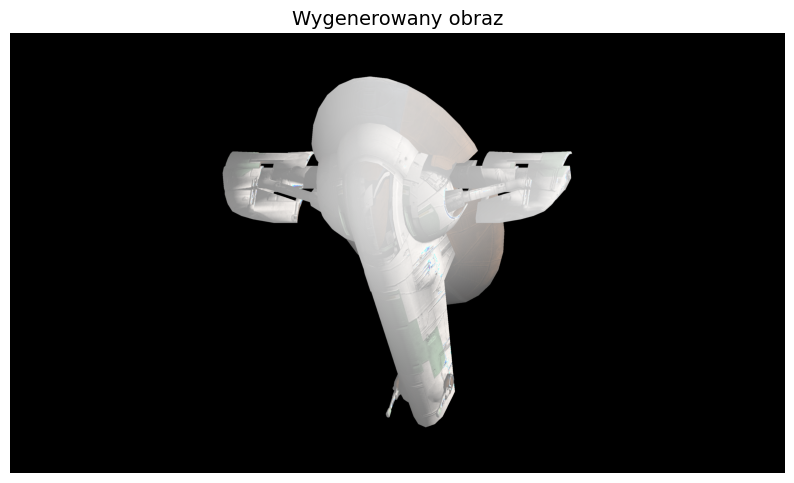

In [ ]:
# 1. Przeskalowanie wartości z przedziału [0.0, 1.0] do [0, 255]
# Jeśli Twoje dane z OpenGL są w innym formacie i mają już wartości 0-255, pomin to mnożenie.
image_data_uint8 = (buffer_data * 255).astype(np.uint8)

# 2. Utworzenie obiektu obrazu na podstawie tablicy NumPy
# Mode 'RGBA' oznacza, że mamy 4 kanały: Red, Green, Blue, Alpha
image = Image.fromarray(image_data_uint8, mode='RGBA')

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.title("Wygenerowany obraz", fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
pip install moderngl-window pyrr Pillow numpy

In [ ]:
import numpy as np
import trimesh

# =====================================================================
# KROK 7: ZAPIS CHMURY PUNKTÓW DO PLIKU PLY (Architektura GPU)
# =====================================================================

# 1. Identyfikacja poprawnych fragmentów.
# Szukamy pikseli, gdzie Z jest mniejsze niż 1.0 (tło).
# Używamy tolerancji < 0.9999 z powodu specyfiki zapisu zmiennoprzecinkowego
# w pamięci VRAM (Depth24/Depth32F), aby uniknąć błędów zaokrągleń (floating point inaccuracies).
valid_y, valid_x = np.where(z_buffer < 0.9999)

# 2. Ekstrakcja głębokości z bufora
valid_z_normalized = z_buffer[valid_y, valid_x]

# 2.1. Ekstrakcja amplitudy dla usuniętych punktów
valid_color = color_buffer[valid_y, valid_x]

# =====================================================================
# UWAGA INŻYNIERYJNA: REKONSTRUKCJA GŁĘBOKOŚCI
# Zmienna `valid_z_normalized` przechowuje wartości od 0.0 do 1.0.
# Jeśli wstawisz je bezpośrednio obok `valid_x` (np. 500 px) i `valid_y`,
# Twoja chmura punktów będzie drastycznie "spłaszczona" na osi Z.
#
# Aby przywrócić pierwotne proporcje (World Space), musimy odwrócić
# sprzętowe rzutowanie, korzystając z parametrów `near` i `far`,
# których użyliśmy w macierzy `ortho_matrix` (od -1000.0 do +1000.0).
# =====================================================================
# Mapowanie liniowe z [0, 1] powrót do skali obiektu

# 1. Dekompresja sprzętowa: powrót z [0, 1] do rzeczywistych jednostek świata
valid_z_world_absolute = (valid_z_normalized * (far_plane - near_plane)) + near_plane

# 2. Przejście do przestrzeni "pikseli" (aby zrównać proporcje z osiami X i Y)
# Używamy tej samej skali (scale), którą obliczyliśmy na początku dla ekranu.
valid_z_pixel_space = (valid_z_world_absolute - z_center) * scale

# 3. Budowa macierzy punktów o jednorodnych jednostkach (wszystko w skali ekranu)
point_cloud_array = np.column_stack((valid_x, valid_y, valid_z_pixel_space))

#=========NOWOSC=========

# KONWERSJA AMPLITUDY DO SKALI SZAROŚCI W FORMACIE PLY (RGB/RGBA)
# Zmieniamy wartość 0.0-1.0 na 0-255 uint8 dla formatu koloru wierzchołków (Vertex Colors).
# Zdecydowana większość programów (np. CloudCompare) tak odczytuje intensywność.
amplitudes_8bit = (np.clip(valid_color, 0.0, 1.0) * 255).astype(np.uint8)

print(f"\nWygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: {len(point_cloud_array)}")

# 4. Inicjalizacja struktury i serializacja do pliku .ply
ply_filename = "/content/drive/MyDrive/pointcloud/zmienNazwe_gpu_kolor.ply"
pcd = trimesh.points.PointCloud(point_cloud_array, colors=valid_color)
pcd.export(ply_filename)

print(f"Pomyślnie zapisano sprzętową chmurę punktów do pliku: {ply_filename}")


Wygenerowano chmurę punktów z GPU Z-bufora! Liczba punktów: 1216295
Pomyślnie zapisano sprzętową chmurę punktów do pliku: /content/drive/MyDrive/pointcloud/zmienNazwe_gpu_kolor.ply
